In [1]:
import cafe

# cafe.logger.setLevel("DEBUG")
# img_dir = "img/26.04.08-benchmark_pancreas"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

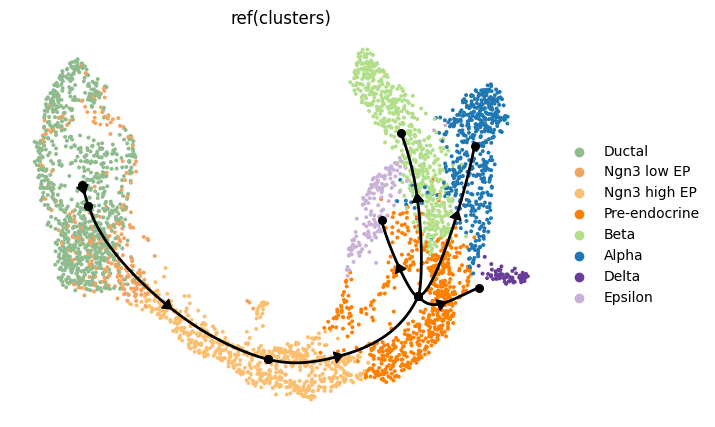

In [2]:
fadata = cafe.data.read_pancreas()
cafe.plot.plot_trajectory(fadata) # waypoint wrapper
fadata

benchmark method run

In [3]:
fadata.load_trajectory_dict("scvelo")

benchmark method caculation and normalization

In [12]:
benchmark_df = cafe.benchmark.metrics(fadata, overall_score_func=True, if_save=True, if_impute=False)
benchmark_df

INFO     |- no model_name_list provided, use all methods in method yaml file: ['comp1', 'palantir', 'scvelo']                                                                                           
INFO     |- metric file for model 'comp1' already exists. read it.                                                                                                                                      
INFO     |- model comp1 missing metrics: ['velocity_cbdir', 'velocity_icvcoh'], recalculating...                                                                                                        
INFO     |- pseudo velocity don't exist, compute and add it to raw_wrapper_dict                                                                                                                         
INFO     |- metric file for model 'palantir' already exists. read it.                                                                                                                               

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,correlation,rf_mse,rf_nmse,rf_rsq,lm_nmse,lm_mse,lm_rsq,...,F1_branches,F1_milestones,harm_mean,geom_mean,arith_mean,time,time_text,memory,memory_text,overall
comp1,0.950242,0.676560,0.999876,0.738601,0.851693,0.441695,0.398966,0.220615,0.792965,0.178980,...,0.189011,0.281500,0.281500,0.281500,0.281500,0.0,0s,0.0,0M,0.424410
palantir,0.990816,0.686096,0.999869,0.674271,0.890567,0.588036,0.510696,0.202695,0.788205,0.158187,...,0.189011,0.271796,0.271796,0.271796,0.271796,0.0,0s,0.0,0M,0.430373
scvelo,1.000000,0.773555,0.907806,0.928716,0.999998,0.999993,0.999989,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0s,0.0,0M,0.937827


In [ ]:
milestone_network = fadata.get_milestone_wrapper("ref").milestone_network
cluster_edges = milestone_network[["from", "to"]].values.tolist()

cafe.metric.calculate_velocity_metrics(fadata, cluster_edges=cluster_edges)

INFO     |- pseudo velocity don't exist, compute and add it to raw_wrapper_dict                                                                                                                         


{'velocity_cbdir': 0.3930247022638121, 'velocity_icvcoh': 0.8945382378766017}

重新预处理之后仍然报错

In [9]:
# from cafe.method.function.preprocess_pipeline import scanpy_preprocess_pipeline

# scanpy_preprocess_pipeline(fadata)
# cafe.metric.calculate_velocity_metrics(fadata, cluster_edges=cluster_edges)

尝试导入VeloAE原生的指标计算方法，无法在当前环境计算完成

In [10]:
# import sys

# sys.path.append("/root/miniconda3/envs/veloae/lib/python3.10/site-packages/veloproj/")

# from eval_util import evaluate


# # transfer to AnnData object and add velocity_umap to obsm
# adata = fadata.to_anndata()
# adata.obsm["velocity_umap"] = fadata.get_raw_wrapper_dict("scvelo")["velocity_umap"]

# # 老版本的邻居计算会保存indices，不能在此处直接使用
# evaluate(adata, cluster_edges=cluster_edges, k_cluster="clusters", k_velocity="velocity")


bug原因定位，当前版本的预处理neighbor之后结果，有效邻居数量不固定，因此提取

In [11]:
distances = fadata.obsp["distances"]
valid_neighbor_num_list = (distances.toarray()>0).sum(axis=1)
n_neighbors = fadata.uns["neighbors"]["params"]["n_neighbors"].item()
print(f"各个细胞有效邻居数量: {valid_neighbor_num_list}")
print(f"预期细胞邻居数量: {n_neighbors}")

各个细胞有效邻居数量: [12 14  9 ... 14  1  9]
预期细胞邻居数量: 15
